In [19]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sym
x, y = sym.symbols('x, y')
plt.rcParams['figure.figsize'] = [40, 40]

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from scipy.integrate import odeint

# Initialize pretty printing
sym.init_printing()

def get_user_input():
    """
    Handles user interaction.
    Accepts 2 inputs for a square grid: "x_min, x_max" (applies to Y too)
    Accepts 4 inputs for a custom grid: "x_min, x_max, y_min, y_max"
    """
    try:
        raw_rng = input("Enter range (x_min, x_max) OR (x_min, x_max, y_min, y_max): ").split(',')
        vals = [float(val.strip()) for val in raw_rng]

        if len(vals) == 2:
            # User provided 2 numbers -> Square Grid
            # Format: [x_min, x_max, y_min, y_max]
            rng = [vals[0], vals[1], vals[0], vals[1]]
        elif len(vals) == 4:
            # User provided 4 numbers -> Rectangular Grid
            rng = vals
        else:
            print("Error: Please enter exactly 2 or 4 numbers.")
            return None, None

        raw_func = input("Enter dy/dx (e.g., 1/3 * (y-3)**3): ")
        function = sym.sympify(raw_func)

        return rng, function
    except Exception as e:
        print(f"Error parsing input: {e}")
        return None, None

def plot_slope_field(ax, limits, func_expr, num_points=25):
    """
    Plots the slope field. 'limits' must be [x_min, x_max, y_min, y_max].
    """
    x, y = sym.symbols('x y')
    f_numeric = sym.lambdify((x, y), func_expr, 'numpy')

    # Unpack limits
    x_min, x_max, y_min, y_max = limits

    # Create separate grids for X and Y based on their specific limits
    x_space = np.linspace(x_min, x_max, num_points)
    y_space = np.linspace(y_min, y_max, num_points)
    X, Y = np.meshgrid(x_space, y_space)

    dx = np.ones_like(X)
    dy = f_numeric(X, Y)

    # Normalize
    magnitude = np.sqrt(dx**2 + dy**2)
    magnitude[magnitude == 0] = 1

    ax.quiver(X, Y, dx/magnitude, dy/magnitude, pivot='mid', color='gray', alpha=0.5)

    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')

    # Only force aspect='equal' if the user entered a square grid
    # Otherwise, let matplotlib stretch it to fit the window
    if (x_max - x_min) == (y_max - y_min):
        ax.set_aspect('equal')

    ax.grid(True, alpha=0.3)
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])

def plot_particular_solution(ax, limits, func_expr, x0, y0):
    """
    Plots a specific solution curve.
    """
    x, y = sym.symbols('x y')
    f_numeric = sym.lambdify((x, y), func_expr, 'numpy')

    # Unpack limits to know how far to integrate
    x_min, x_max, _, _ = limits

    def model(y_val, x_val):
        return f_numeric(x_val, y_val)

    # Integrate from x0 to the edges of the view window
    x_right = np.linspace(x0, x_max, 200)
    x_left = np.linspace(x0, x_min, 200)

    # Run integration (wrapped in try/except for singularities)
    try:
        y_right = odeint(model, y0, x_right)
        y_left = odeint(model, y0, x_left)

        ax.plot(x_right, y_right.flatten(), 'r-', linewidth=2, label=f'Sol thru ({x0}, {y0})')
        ax.plot(x_left, y_left.flatten(), 'r-', linewidth=2)
        ax.plot(x0, y0, 'ro')
    except Exception as e:
        print(f"Could not plot particular solution: {e}")

def solve_analytical(func_expr, x0=None, y0=None):
    """
    Solves ODE symbolically. returns General Sol if x0/y0 missing.
    """
    x, y = sym.symbols('x y')
    y_func = sym.Function('y')(x)

    print("\nAttempting to solve analytically...")

    try:
        ode_rhs = func_expr.subs(y, y_func)
        diffeq = sym.Eq(y_func.diff(x), ode_rhs)

        gen_sol = sym.dsolve(diffeq, y_func)

        if x0 is None or y0 is None:
            print("General solution found.")
            return gen_sol

        print("General solution found. Attempting particular solution...")
        try:
            part_sol = sym.dsolve(diffeq, y_func, ics={y_func.subs(x, x0): y0})
            return part_sol
        except Exception:
            print("Particular solution failed. Returning general solution.")
            return gen_sol

    except Exception as e:
        print(f"Could not solve symbolically: {e}")
        return None

# This works but I don't want it running every time, so I have it commented out
if __name__ != '__main__':
    # Getting input
    input_result = get_user_input()

    # Check if input_result is valid before unpacking
    if input_result[0] is not None:
        limits, func = input_result

        # Define start point for particular solution
        # TODO make this come from input
        start_x, start_y = 2, 1

        # Plotting
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.set_title("Slope Field")

        plot_slope_field(ax, limits, func)
        plot_particular_solution(ax, limits, func, start_x, start_y)

        plt.legend()
        plt.show()

        # Math
        sol = solve_analytical(func, start_x, start_y)

        if sol is not None:
            display(sol)

# Finding Particular Solution and Plotting with Slope Field

Finding general solution...

Attempting to solve analytically...
General solution found.


       4⋅C₁ - 4⋅x + 1
y(x) = ──────────────
           C₁ - x    

Finding solution for dy/dx = (y - 4)**2 passing through (0.5, 0.5)...

Attempting to solve analytically...
General solution found. Attempting particular solution...


       1.85714285714286 - 4⋅x
y(x) = ──────────────────────
       0.214285714285714 - x 

ValueError: not enough values to unpack (expected 4, got 2)

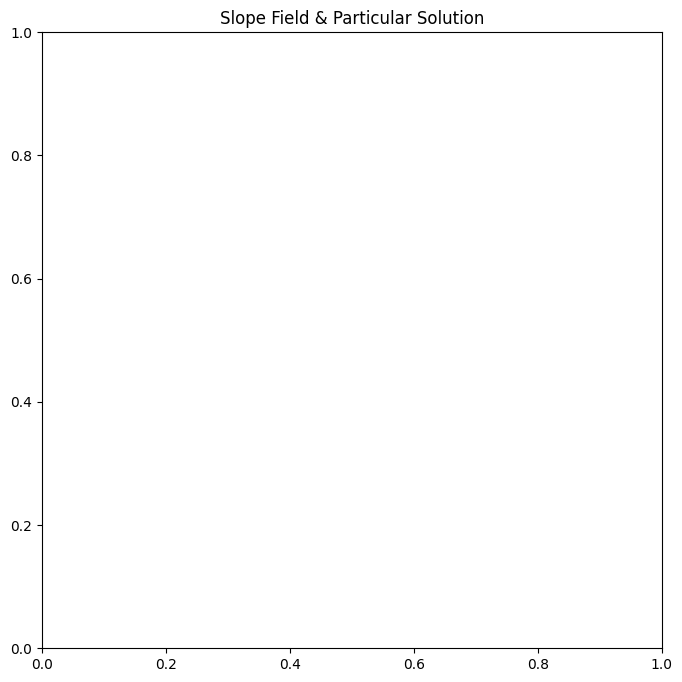

In [21]:
# Define symbols that we can use in the equations
x, y = sym.symbols('x y')

# Inputs
range = [-5, 5]
func = (y-4)**2
start_x, start_y = 0.5, 0.5

# Getting and displaying the general soltuion
print("Finding general solution...")
general_solution = solve_analytical(func)
display(general_solution)

# Displaying the particular solution
print(f"Finding solution for dy/dx = {func} passing through ({start_x}, {start_y})...")
sol = solve_analytical(func, start_x, start_y)
display(sol)

# Plotting stuff
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title(f"Slope Field & Particular Solution")
plot_slope_field(ax, range, func)
plot_particular_solution(ax, range, func, start_x, start_y)
plt.legend()
plt.show()